# **Задание 6.** Distillation

## Импорт библиотек и модулей

In [1]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import random
import cv2
import copy

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from typing import Optional, Callable

from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import accuracy_score as acc, precision_score as P, recall_score as R, confusion_matrix as cm, classification_report as report
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchvision as tv
import torchvision.transforms.v2 as T
import albumentations as A
from albumentations.pytorch import ToTensorV2
from transformers import CLIPModel, CLIPProcessor

import kagglehub as kaggle
import datasets as ds

Зададим значение `seed` и зафиксируем его:

In [2]:
seed_value = 927

random.seed(seed_value)
torch.manual_seed(seed_value)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.mps.is_available() else
    "cpu"
)
print(f"Using device: {device}")

Using device: mps


## Загрузка датасета

In [4]:
data_path = kaggle.dataset_download("cashbowman/ai-generated-images-vs-real-images")
print(f"Path to the dataset: {data_path}")

Path to the dataset: /Users/dji/.cache/kagglehub/datasets/cashbowman/ai-generated-images-vs-real-images/versions/1


## Реализация датасета

In [5]:
class CustomDataset(Dataset):
    def __init__(
        self,
        data_path: str,
        train: bool = True,
        transform: Optional[Callable] = None
    ):
        self.data_path = data_path
        self.realart_path = os.path.join(self.data_path, "RealArt", "RealArt")
        self.aiart_path = os.path.join(self.data_path, "AiArtData", "AiArtData")

        all_imgs = dict()
        for path, label in zip([self.realart_path, self.aiart_path],
                               [0, 1]):
            imgs = os.listdir(path)
            for img in imgs:
                all_imgs[os.path.join(path, img)] = label

        paths, labels = list(all_imgs.keys()), list(all_imgs.values())
        t_paths, v_paths, t_labels, v_labels = tts(
            paths, labels,
            test_size=0.2,
            random_state=seed_value,
            stratify=labels
        )

        self.train = train
        if train:
            self.paths, self.labels = t_paths, t_labels
        else:
            self.paths, self.labels = v_paths, v_labels

        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path, label = self.paths[idx], self.labels[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            tfm = self.transform(image=img, train=self.train)
            img = tfm['image']

        return img, torch.tensor(label, dtype=torch.long)

## Задание аугментаций

In [6]:
def get_transform(train: bool = True):
    if train:
        return A.Compose([
            A.Resize(256, 256),
            A.RandomCrop(224, 224),
            A.RandomBrightnessContrast(
                brightness_limit=0.2,
                contrast_limit=0.2,
                p=0.5
            ),
            A.OneOf([
                A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=0.5),
                A.Blur(blur_limit=3, p=0.3),
                A.GaussianBlur(blur_limit=(3, 5), sigma_limit=0.5, p=0.3),
            ], p=0.6),
            A.OneOf([
                A.GaussNoise(p=0.5),
                A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.5),
            ], p=0.5),
            A.HueSaturationValue(
                hue_shift_limit=10,
                sat_shift_limit=20,
                val_shift_limit=15,
                p=0.4
            ),
            A.ShiftScaleRotate(
                shift_limit=0.05,
                scale_limit=0.05,
                rotate_limit=5,
                border_mode=cv2.BORDER_REFLECT,
                p=0.4
            ),
            A.Emboss(alpha=(0.2, 0.5), strength=(0.2, 0.7), p=0.2),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

## Реализация создания даталоадера

In [7]:
def create_custom_dl(
    data_path: str,
    train: bool = True
):
    ds = CustomDataset(
        data_path=data_path,
        train=train,
        transform=get_transform(train=train)
    )
    dl = DataLoader(
        dataset=ds,
        batch_size=64,
        shuffle=(True if train else False),
        num_workers=0
    )
    return dl

In [8]:
train_dl = create_custom_dl(data_path=data_path, train=True)
val_dl = create_custom_dl(data_path=data_path, train=False)

/opt/homebrew/anaconda3/envs/nn-arch-venv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Модель-учитель

In [9]:
teacher = tv.models.resnet50(pretrained=True)

/opt/homebrew/anaconda3/envs/nn-arch-venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/anaconda3/envs/nn-arch-venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
def evaluate(model, dataloader, criterion=None):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in tqdm(dataloader, desc="Evaluation", leave=False):
            x, y = x.to(device), y.to(device)

            out = model(x)

            if criterion:
                loss = criterion(out, y)
                total_loss += loss.item()

            preds = torch.argmax(out, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / len(dataloader) if criterion else 0
    accuracy = acc(all_labels, all_preds)

    return avg_loss, accuracy

In [11]:
def train(model, train_dataloader, val_dataloader, epochs=15, lr=1e-4, weight_decay=1e-5):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    
    train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
    val_best = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_samples = 0
        
        progress_bar = tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{epochs}')
        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            
            with torch.autocast(
                device_type=device.type,
                dtype=torch.bfloat16,
            ):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size
            progress_bar.set_postfix({'loss': loss.item()})
        
        avg_train_loss = total_loss / total_samples
        train_losses.append(avg_train_loss)
        
        _, train_acc = evaluate(model, train_dataloader, criterion)
        val_loss, val_acc = evaluate(model, val_dataloader, criterion)
        if val_acc > val_best:
            torch.save(model.state_dict(), "best.pth")
            val_best = val_acc
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        
        print(f'Epoch {epoch+1}/{epochs}: '
              f'Train Loss: {avg_train_loss:.4f}, '
              f'Val Loss: {val_loss:.4f}, '
              f'Val Acc: {val_acc:.4f}')

    return train_losses, val_losses, train_accuracies, val_accuracies

In [12]:
teacher_train_loss, teacher_val_loss, teacher_train_acc, teacher_val_acc = train(
    teacher, train_dl, val_dl, epochs=10, lr=1e-4, weight_decay=1e-4
)

Evaluation:  54%|█████▍    | 7/13 [00:07<00:06,  1.08s/it]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Epoch 1/10: Train Loss: 7.0341, Val Loss: 6.9581, Val Acc: 0.3744


Evaluation:  85%|████████▍ | 11/13 [00:11<00:02,  1.06s/it]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Epoch 2/10: Train Loss: 2.5326, Val Loss: 4.3585, Val Acc: 0.4462


Evaluation:  62%|██████▏   | 8/13 [00:08<00:05,  1.06s/it]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


...

Epoch 8/10: Train Loss: 0.2148, Val Loss: 0.6345, Val Acc: 0.8769


Evaluation:   8%|▊         | 1/13 [00:01<00:13,  1.12s/it]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Epoch 9/10: Train Loss: 0.2125, Val Loss: 0.6087, Val Acc: 0.8513


Evaluation:  15%|█▌        | 2/13 [00:02<00:11,  1.03s/it]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space
                                                           

Epoch 10/10: Train Loss: 0.1419, Val Loss: 0.5307, Val Acc: 0.8718


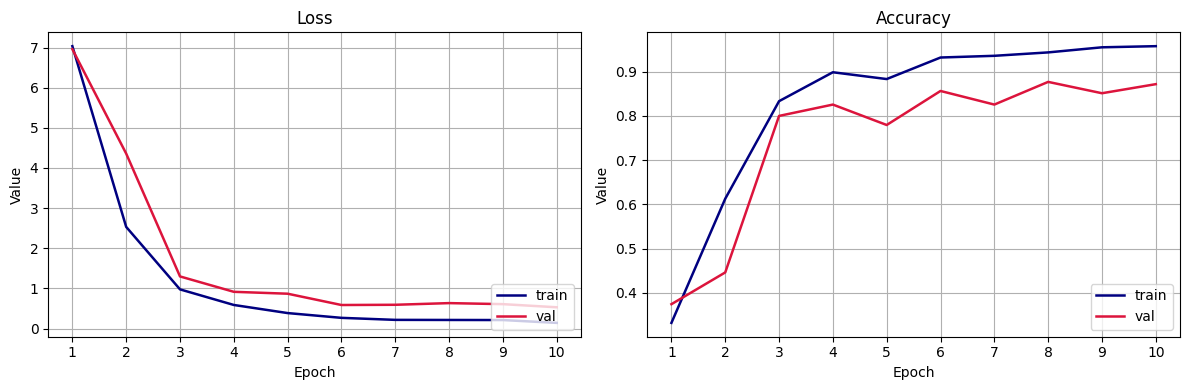

In [13]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(teacher_train_loss, color='navy', label='train', lw=1.8)
plt.plot(teacher_val_loss, color='crimson', label='val', lw=1.8)
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Loss')
plt.xticks(range(0, 10), range(1, 11))
plt.grid()
plt.legend(loc='lower right')
plt.subplot(122)
plt.plot(teacher_train_acc, color='navy', label='train', lw=1.8)
plt.plot(teacher_val_acc, color='crimson', label='val', lw=1.8)
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Accuracy')
plt.xticks(range(0, 10), range(1, 11))
plt.grid()
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Модель-студент (без дистилляции)

In [14]:
student = tv.models.resnet18(pretrained=True)

/opt/homebrew/anaconda3/envs/nn-arch-venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/anaconda3/envs/nn-arch-venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
student_train_loss, student_val_loss, student_train_acc, student_val_acc = train(
    student, train_dl, val_dl, epochs=10, lr=1e-4, weight_decay=1e-4
)

Evaluation:  62%|██████▏   | 8/13 [00:06<00:03,  1.29it/s]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space
/opt/homebrew/anaconda3/envs/nn-arch-venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")


Epoch 1/10: Train Loss: 8.7566, Val Loss: 8.9094, Val Acc: 0.1179


Evaluation:  85%|████████▍ | 11/13 [00:08<00:01,  1.34it/s]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Epoch 2/10: Train Loss: 4.9166, Val Loss: 6.1487, Val Acc: 0.4051


Evaluation:  38%|███▊      | 5/13 [00:04<00:06,  1.25it/s]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


...

Epoch 8/10: Train Loss: 0.4835, Val Loss: 1.3174, Val Acc: 0.8154


Evaluation:  38%|███▊      | 5/13 [00:04<00:06,  1.31it/s]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Epoch 9/10: Train Loss: 0.3007, Val Loss: 1.2444, Val Acc: 0.8308


Evaluation:   0%|          | 0/13 [00:00<?, ?it/s]libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space
                                                           

Epoch 10/10: Train Loss: 0.2668, Val Loss: 1.1021, Val Acc: 0.8410


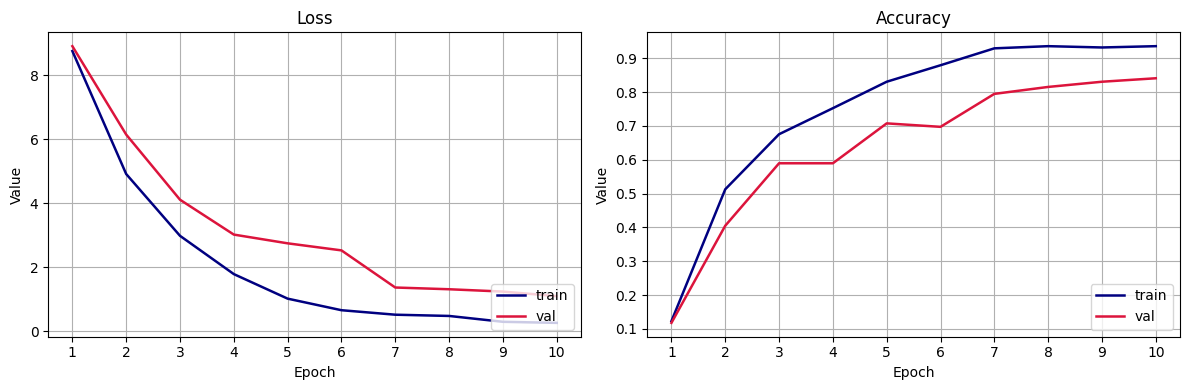

In [16]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(student_train_loss, color='navy', label='train', lw=1.8)
plt.plot(student_val_loss, color='crimson', label='val', lw=1.8)
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Loss')
plt.xticks(range(0, 10), range(1, 11))
plt.grid()
plt.legend(loc='lower right')
plt.subplot(122)
plt.plot(student_train_acc, color='navy', label='train', lw=1.8)
plt.plot(student_val_acc, color='crimson', label='val', lw=1.8)
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Accuracy')
plt.xticks(range(0, 10), range(1, 11))
plt.grid()
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Модель-студент (с дистилляцией)

In [17]:
class ResNetDistilTrainer:
    def __init__(
        self,
        teacher_model,
        student_model,
        temperature=3.0,
        alpha=0.7,
    ):
        self.device = device
        self.temperature = temperature
        self.alpha = alpha
        
        self.teacher = teacher_model
        for param in self.teacher.parameters():
            param.requires_grad = False
        self.teacher = self.teacher.to(device).eval()
        self.student = student_model
        self.student = self.student.to(device)
        self.criterion_kl = nn.KLDivLoss(reduction="batchmean")
        self.criterion_ce = nn.CrossEntropyLoss()
        self.best_val_acc = 0.0
        self.best_weights = None
    
    def calculate_loss(self, student_logits, images, labels):
        with torch.no_grad():
            teacher_logits = self.teacher(images)

        soft_targets = F.softmax(teacher_logits / self.temperature, dim=1)
        soft_preds = F.log_softmax(student_logits / self.temperature, dim=1)
        
        kl_loss = self.criterion_kl(soft_preds, soft_targets) * (self.temperature ** 2)
        ce_loss = self.criterion_ce(student_logits, labels)
        
        total_loss = self.alpha * kl_loss + (1 - self.alpha) * ce_loss
        return total_loss, kl_loss, ce_loss
    
    def train(self, train_dataloader, val_dataloader, epochs=15, lr=1e-4, weight_decay=1e-5):
        optimizer = torch.optim.AdamW(self.student.parameters(), lr=lr, weight_decay=weight_decay)
        
        train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []
        self.best_val_acc = 0.0
        
        dtype = torch.bfloat16
        
        for epoch in range(epochs):
            self.student.train()
            total_loss = 0.0
            total_samples = 0
            
            progress_bar = tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{epochs}')
            for images, labels in progress_bar:
                images = images.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True)
                
                optimizer.zero_grad()
                with torch.autocast(
                    device_type=self.device.type,
                    dtype=dtype
                ):
                    student_logits = self.student(images)
                    loss, kl_loss, ce_loss = self.calculate_loss(student_logits, images, labels)
                
                loss.backward()
                optimizer.step()
                
                batch_size = images.size(0)
                total_loss += loss.item() * batch_size
                total_samples += batch_size
                progress_bar.set_postfix({'loss': f"{loss.item():.4f}", 'kl': f"{kl_loss.item():.4f}", 'ce': f"{ce_loss.item():.4f}"})
            
            avg_train_loss = total_loss / total_samples
            train_losses.append(avg_train_loss)
            
            _, train_acc = self.evaluate(self.student, train_dataloader)
            val_loss, val_acc = self.evaluate(self.student, val_dataloader)
            
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.best_weights = copy.deepcopy(self.student.state_dict())
            
            val_losses.append(val_loss)
            train_accuracies.append(train_acc)
            val_accuracies.append(val_acc)
            
            print(f'Epoch {epoch+1}/{epochs}: '
                  f'Train Loss: {avg_train_loss:.4f}, '
                  f'Val Loss: {val_loss:.4f}, '
                  f'Train Acc: {train_acc:.4f}, '
                  f'Val Acc: {val_acc:.4f}')
        
        if self.best_weights is not None:
            self.student.load_state_dict(self.best_weights)
            torch.save(self.best_weights, "best_student_kd.pth")
        
        return train_losses, val_losses, train_accuracies, val_accuracies
    
    def evaluate(self, model, dataloader):
        model.eval()
        total_loss = 0.0
        total_samples = 0
        correct = 0
        
        with torch.no_grad():
            for images, labels in dataloader:
                images = images.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True)
                
                outputs = model(images)
                loss = self.criterion_ce(outputs, labels)
                
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                
                batch_size = images.size(0)
                total_loss += loss.item() * batch_size
                total_samples += batch_size
        
        avg_loss = total_loss / total_samples
        accuracy = correct / total_samples
        return avg_loss, accuracy
    
    def predict(self, x):
        self.student.eval()
        with torch.no_grad():
            return self.student(x)

In [18]:
teacher.load_state_dict(torch.load("best_teacher.pth"))
student.load_state_dict(torch.load("best_student.pth"))

kd_trainer = ResNetDistilTrainer(
    teacher_model=teacher,
    student_model=student,
    temperature=6.0,
    alpha=0.2
)

train_losses, val_losses, train_accs, val_accs = kd_trainer.train(
    train_dataloader=train_dl,
    val_dataloader=val_dl,
    epochs=10,
    lr=1e-4,
    weight_decay=1e-4
)

Epoch 1/10: 100%|██████████| 13/13 [00:23<00:00,  1.78s/it, loss=0.3096, kl=1.0126, ce=0.1338]
libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Epoch 1/10: Train Loss: 0.4459, Val Loss: 5.6556, Train Acc: 0.4436, Val Acc: 0.3282


Epoch 2/10: 100%|██████████| 13/13 [00:23<00:00,  1.78s/it, loss=0.9770, kl=0.8243, ce=1.0151]
libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Epoch 2/10: Train Loss: 0.3689, Val Loss: 5.8918, Train Acc: 0.5346, Val Acc: 0.6923


Epoch 3/10: 100%|██████████| 13/13 [00:23<00:00,  1.78s/it, loss=0.4429, kl=0.5565, ce=0.4145]
libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


...

Epoch 8/10: Train Loss: 0.1951, Val Loss: 3.6330, Train Acc: 0.5487, Val Acc: 0.6974


Epoch 9/10: 100%|██████████| 13/13 [00:23<00:00,  1.81s/it, loss=0.1909, kl=0.4695, ce=0.1213]
libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Epoch 9/10: Train Loss: 0.2163, Val Loss: 6.7634, Train Acc: 0.5103, Val Acc: 0.4769


Epoch 10/10: 100%|██████████| 13/13 [00:23<00:00,  1.80s/it, loss=0.1129, kl=0.4034, ce=0.0403]
libpng warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


Epoch 10/10: Train Loss: 0.1548, Val Loss: 5.5104, Train Acc: 0.6141, Val Acc: 0.5385


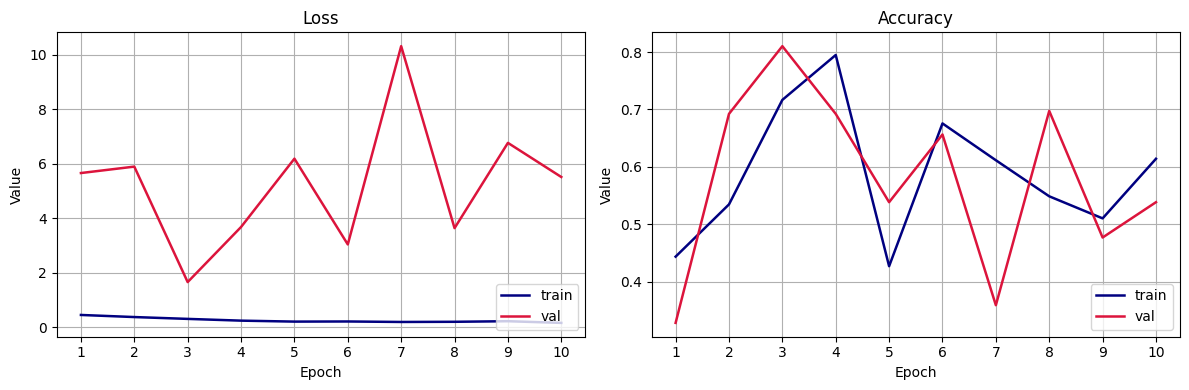

In [19]:
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(train_losses, color='navy', label='train', lw=1.8)
plt.plot(val_losses, color='crimson', label='val', lw=1.8)
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Loss')
plt.xticks(range(0, 10), range(1, 11))
plt.grid()
plt.legend(loc='lower right')
plt.subplot(122)
plt.plot(train_accs, color='navy', label='train', lw=1.8)
plt.plot(val_accs, color='crimson', label='val', lw=1.8)
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Accuracy')
plt.xticks(range(0, 10), range(1, 11))
plt.grid()
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Вывод

Модели из torchvision без дистилляции показали лучшие результаты, чем с дистилляцией. Возможно, есть ошибка, так как переобучение (которое подтверждается графиками лосса и accuracy) не характерно для такого количества эпох. Возможно, для дистилляции нужно больше эпох с другими параметрами.

upd: после взятия других гиперпараметров обучение стало менее стабильным, но метрики подросли